In [ ]:
!python -m pip install numpy pandas scikit-learn xgboost seaborn matplotlib -q

In [ ]:
!python -m pip install jinja2 -q

## Data Cleaning and Preprocessing

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [5]:
df = pd.read_csv("./data/cropdata_updated.csv")
print(f"Raw Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head(10)

Raw Dataset Shape: 16411 rows, 7 columns



,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1
5,Wheat,Black Soil,Germination,6,30,65.0,1
6,Wheat,Black Soil,Germination,7,31,62.0,1
7,Wheat,Black Soil,Germination,8,32,59.0,1
8,Wheat,Black Soil,Germination,9,33,56.0,1
9,Wheat,Black Soil,Germination,10,34,53.0,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  str    
 1   soil_type       16411 non-null  str    
 2   Seedling Stage  16411 non-null  str    
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 897.6 KB


In [7]:
df.drop_duplicates(inplace=True)
df.shape

(16283, 7)

In [8]:
df = df[df["result"] != 2]
df.shape

(15161, 7)

In [9]:
target_counts = df['result'].value_counts().sort_index()
target_pct = df['result'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct.round(2),
    'Description': [
        '0: No Irrigation',
        '1: Standard Irrigation',
    ]
})
target_summary

,Count,Percentage (%),Description
result,,,
0,8934,58.93,0: No Irrigation
1,6227,41.07,1: Standard Irrigation


In [10]:
df.rename(columns={
    "crop ID": "crop_name",
    "soil_type": "soil_type",
    "Seedling Stage": "seedling_stage",
    "MOI": "moi",
    "temp": "temp",
    "humidity": "humidity",
    "result": "result",
}, inplace=True)
df.head()

,crop_name,soil_type,seedling_stage,moi,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [11]:
numerical_cols = ['moi', 'temp', 'humidity']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"The column {col} has {len(outliers)} outliers that has a percentage of {round((len(outliers) / len(df)) * 100, 2)}%")



The column moi has 0 outliers that has a percentage of 0.0%
The column temp has 0 outliers that has a percentage of 0.0%
The column humidity has 0 outliers that has a percentage of 0.0%


In [12]:
GROWTH_STAGE_ORDER_MAP = {
    "Germination": 1,
    "Seedling Stage": 2,
    "Vegetative Growth / Root or Tuber Development": 3,
    "Flowering": 4,
    "Pollination": 5,
    "Fruit/Grain/Bulb Formation": 6,
    "Maturation": 7,
    "Harvest": 8,
}
df["growth_stage_order"] = (df["seedling_stage"].map(GROWTH_STAGE_ORDER_MAP).fillna(0).astype(int))

In [13]:
df["moi_temp_ratio"] = (df["moi"] / df["temp"].replace(0, np.nan)).round(4)
df["moi_humidity_index"] = ((df["moi"] * df["humidity"]) / 100.0).round(4)
df.shape

(15161, 10)

In [14]:
df.to_csv("./data/cleaned_data.csv", index=False)

In [15]:
numerical_cols = ["moi", "temp", "humidity", "growth_stage_order", "moi_temp_ratio", "moi_humidity_index"]
categorical_cols = ["crop_name", "soil_type"]
feature_cols = categorical_cols + numerical_cols
X = df[feature_cols]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [16]:
processor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [17]:
X_train_transformed = processor.fit_transform(X_train)
X_test_transformed = processor.transform(X_test)
feature_names = processor.get_feature_names_out()

X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)


## Machine Learning Models Training 

We train and evaluate multiple classification models on the preprocessed dataset:
1. **Logistic Regression** (Linear baseline)
2. **K-Nearest Neighbors (KNN)** (Distance-based)
3. **Decision Tree** (Interpretable tree)
4. **Random Forest** (Bagging ensemble)
5. **XGBoost** (Gradient boosted trees)
6. **Support Vector Machine (SVM RBF)** (Kernel method)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss"),
    "SVM (RBF)": SVC(probability=True, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_transformed)
    y_proba = model.predict_proba(X_test_transformed)[:, 1] if hasattr(model, "predict_proba") else None
    
  


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## Machine Learning Models Evaluation

In [34]:
def evaluate_classifier(y_true, y_pred, y_prob, model_name="Model"):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1-Score": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4)
    }

y_pred_lr = trained_models["Logistic Regression"].predict(X_test_transformed)
y_prob_lr = trained_models["Logistic Regression"].predict_proba(X_test_transformed)[:, 1]

y_pred_knn = trained_models["KNN"].predict(X_test_transformed)
y_prob_knn = trained_models["KNN"].predict_proba(X_test_transformed)[:, 1]

y_pred_dt = trained_models["Decision Tree"].predict(X_test_transformed)
y_prob_dt = trained_models["Decision Tree"].predict_proba(X_test_transformed)[:, 1]

y_pred_rf = trained_models["Random Forest"].predict(X_test_transformed)
y_prob_rf = trained_models["Random Forest"].predict_proba(X_test_transformed)[:, 1]

y_pred_xgb = trained_models["XGBoost"].predict(X_test_transformed)
y_prob_xgb = trained_models["XGBoost"].predict_proba(X_test_transformed)[:, 1]

y_pred_svm = trained_models["SVM (RBF)"].predict(X_test_transformed)
y_prob_svm = trained_models["SVM (RBF)"].predict_proba(X_test_transformed)[:, 1]

results = [
    evaluate_classifier(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"),
    evaluate_classifier(y_test, y_pred_knn, y_prob_knn, "K-Nearest Neighbors (KNN)"),
    evaluate_classifier(y_test, y_pred_dt, y_prob_dt, "Decision Tree"),
    evaluate_classifier(y_test, y_pred_rf, y_prob_rf, "Random Forest"),
    evaluate_classifier(y_test, y_pred_xgb, y_prob_xgb, "XGBoost"),
    evaluate_classifier(y_test, y_pred_svm, y_prob_svm, "SVM (RBF)")
]


comparison_df = pd.DataFrame(results)

styled_df = comparison_df.style\
    .background_gradient(cmap='PuBuGn', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])\
    .format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])\
    .set_properties(**{
        'text-align': 'center',
        'padding': '8px 12px',
        'border-color': '#333333'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2d3748'), ('color', 'white')]},
        {'selector': 'caption', 'props': [('caption-side', 'bottom')]}
    ])

display(styled_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9426,0.9489,0.9093,0.9287,0.9863
1,K-Nearest Neighbors (KNN),0.9746,0.9803,0.9575,0.9687,0.9973
2,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
3,Random Forest,0.9980,0.9952,1.0000,0.9976,1.0000
4,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
5,SVM (RBF),0.9842,0.9942,0.9671,0.9805,0.9993


### Test Performance Comparison Insights

* **Top Performers:** Tree-based models (Decision Tree, XGBoost, and Random Forest) achieve the highest overall evaluation metrics, with Test Accuracy ranging from **99.80%** to **100.00%**.
* **Zero False Negatives:** Decision Tree, Random Forest, and XGBoost all reach a perfect **Recall of 1.0000**, ensuring no required irrigation events are missed.
* **Baseline Baseline Models:** Logistic Regression (**94.26%**) and KNN (**97.46%**) lag behind, indicating that environmental features require non-linear decision boundaries.

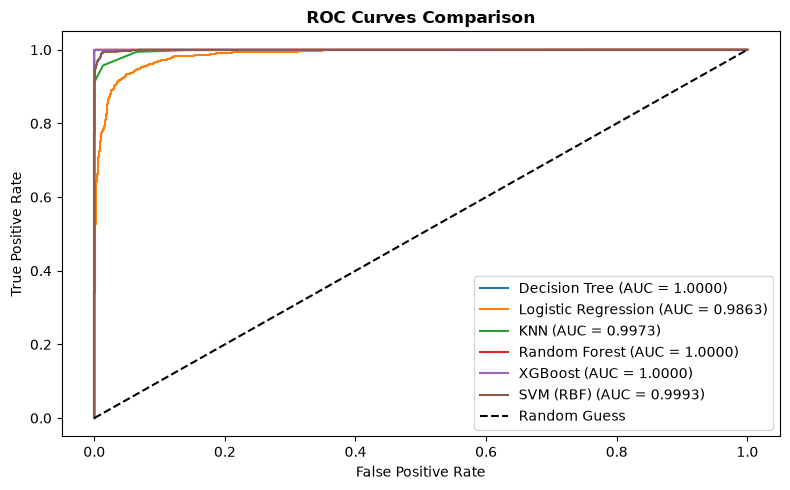

In [42]:
from sklearn.metrics import roc_curve, auc

models_probs = {
    "Decision Tree": y_prob_dt,
    "Logistic Regression": y_prob_lr,
    "KNN": y_prob_knn,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "SVM (RBF)": y_prob_svm
}

plt.figure(figsize=(8, 5))
for name, y_prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [22]:
overfit_check = []

for name, model in trained_models.items():
    train_acc = round(model.score(X_train_transformed, y_train), 4)
    test_acc = round(model.score(X_test_transformed, y_test), 4)
    gap = round(train_acc - test_acc, 4)
    
    overfit_check.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap (Train - Test)": gap
    })

overfit_df = pd.DataFrame(overfit_check)
display(overfit_df)

,Model,Train Accuracy,Test Accuracy,Gap (Train - Test)
0,Logistic Regression,0.9392,0.9426,-0.0034
1,KNN,0.9913,0.9746,0.0167
2,Decision Tree,1.0000,1.0000,0.0000
3,Random Forest,1.0000,0.9980,0.0020
4,XGBoost,1.0000,1.0000,0.0000
5,SVM (RBF),0.9867,0.9842,0.0025


### Overfitting & Generalization Insights

* **Minimal Overfitting Across All Models:** All models demonstrate strong generalization, with the generalization gap between Train Accuracy and Test Accuracy remaining below **1.67%** ($\le 0.0167$).
* **Decision Tree & XGBoost Memorization Risk:** Decision Tree and XGBoost present a zero gap ($0.0000$) with absolute $100\%$ accuracy on both training and testing sets, indicating potential high variance or data memorization.
* **Random Forest Stability:** **Random Forest** exhibits a healthy, minor gap of **0.20%** ($0.0020$), confirming high stability without memorizing noise, making it the most reliable candidate for unseen field conditions.

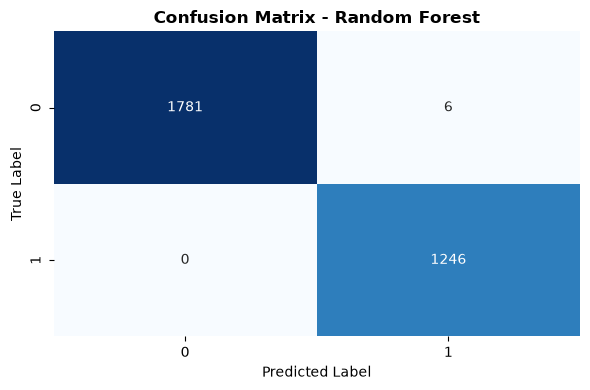

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis (Random Forest)

* **Zero Crop Hazard (FN = 0):** The model achieved **0 False Negatives**, meaning it never missed a single instance where irrigation was actually required (100% Recall). This prevents plant wilting and protects crop yield.
* **Minimal Water Waste (FP = 6):** Out of **3,027** total predictions, only **6 cases** were incorrectly flagged for irrigation when unnecessary (False Positives), resulting in negligible water and energy resource waste.
* **High Operational Accuracy:** The model correctly classified **1,781 Non-Irrigation** and **1,246 Irrigation** events, proving highly reliable decision-making for deployment.

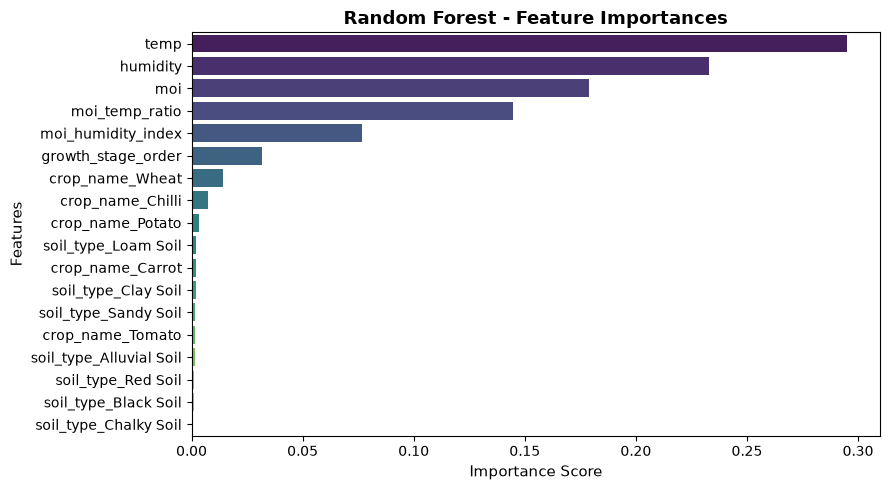

In [40]:
rf_model = trained_models["Random Forest"]

feature_names = X_train_transformed.columns if hasattr(X_train_transformed, 'columns') else [f"Feature {i}" for i in range(X_train_transformed.shape[1])]

importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette="viridis")

plt.title("Random Forest - Feature Importances", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.tight_layout()
plt.show()

### Feature Importance Insights (Random Forest)

* **Primary Environmental Drivers:** Temperature (`temp`), Humidity (`humidity`), and Moisture (`moi`) are the top individual features influencing the irrigation decision, contributing to over 60% of the model's decision-making weight.
* **Impact of Feature Engineering:** Engineered ratios such as `moi_temp_ratio` and `moi_humidity_index` provide significant predictive power, proving that interaction terms between weather and soil moisture effectively guide the model.
* **Low Impact of Categorical Variables:** Specific crop types (e.g., Wheat, Chilli) and soil types (e.g., Loam, Clay) exhibit minimal individual weight, indicating that the immediate environmental state drives irrigation needs more than the static soil/crop categories.